In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import functools
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
import distinctipy

from dti import data
from dti.utils import scaffold_split
from dti.constants import SMILES, ASSAY, ACT

sns.set_context("talk")

In [2]:
FP = "fingerprint"
BUTINA = "_butina"

In [3]:
rng = np.random.default_rng(seed=42)


def get_group_split(df, group_col, test_frac=0.2):
    unique_vals = df[group_col].dropna().unique()
    test_vals = set(
        rng.choice(unique_vals, size=int(len(unique_vals) * test_frac), replace=False)
    )
    test_mask = df[group_col].isin(test_vals)
    return df[~test_mask], df[test_mask], test_vals

In [4]:
data_path = Path("..") / "data" / "raw"

# Splits

## Scaffold

In [5]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv.bkp")
but = pd.read_csv("../data/butina/kinodata/clusters.csv")
df = df.merge(but, left_on=SMILES, right_on="SMILES").rename(
    columns={"cluster": BUTINA}
)

In [6]:
# Remove assays with less than 100 compounds
df = df[df[ASSAY].map(df[ASSAY].value_counts()) > 100]

# Scaffold split the remaining set
df_train, df_test = scaffold_split(df, seed=0)
df_train["scaffold train"] = True
df_test["scaffold train"] = False
df = pd.concat([df_train, df_test])

scaffold:   0%|          | 0/45444 [00:00<?, ?it/s]

## UMAP

In [7]:
# df_train, df_test = umap_split(df)
# df_train["umap train"] = True
# df_test["umap train"] = False
# df = pd.concat([df_train, df_test])

## Butina

In [8]:
_, _, test_vals = get_group_split(df, BUTINA)
test_vals = list(map(int, test_vals))
df["butina train"] = True
df.loc[df[BUTINA].isin(test_vals), "butina train"] = False

## Random

In [9]:
np.random.seed(42)
df["random train"] = np.random.rand(len(df)) > 0.2

## Assay

In [10]:
assays = df[ASSAY].unique()
np.random.seed(0)
np.random.shuffle(assays)
train_assays = assays[: int(len(assays) * 0.8)]
df["assay train"] = df[ASSAY].isin(train_assays)

# Embedding

In [11]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

In [12]:
@functools.cache
def get_fp(smi):
    try:
        return mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smi))
    except:
        return None

In [13]:
df[FP] = [get_fp(smi) for smi in tqdm(df[SMILES].values)]
df = df[~df[FP].isna()]

  0%|          | 0/45444 [00:00<?, ?it/s]

In [14]:
N = 49

## Scaffold split

In [29]:
np.random.seed(42)
assays = np.random.choice(df[ASSAY].unique(), N)
d = df[df[ASSAY].isin(assays)]
# train_assays = assays[:10]
# d.loc[:,'scaffold train'] = d[ASSAY].isin(train_assays)
fp_matrix = np.vstack(d[FP].values)

In [30]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(fp_matrix)

In [31]:
d.loc[:, "tsne-2d-one"] = tsne_results[:, 0]
d.loc[:, "tsne-2d-two"] = tsne_results[:, 1]

/tmp/ipykernel_7652/591977147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d.loc[:,"tsne-2d-one"] = tsne_results[:, 0]
/tmp/ipykernel_7652/591977147.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d.loc[:,"tsne-2d-two"] = tsne_results[:, 1]


In [32]:
cmap = dict(zip(assays, distinctipy.get_colors(len(assays))))
colors = [cmap[aid] for aid in d[ASSAY]]

In [33]:
def scatter_compounds(title, filename, colors, **kwargs):
    plt.figure(figsize=(3.5, 3))
    plt.scatter(d["tsne-2d-one"], d["tsne-2d-two"], c=colors, s=0.8, **kwargs)
    plt.xticks([])
    plt.yticks([])
    # plt.title(title)
    sns.despine(left=True, bottom=True)
    plt.savefig(f"img/{filename}.png", dpi=1000)
    plt.savefig(f"img/{filename}.pdf")

In [34]:
df = df.sample(frac=1)

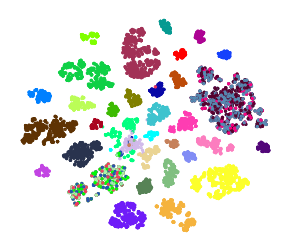

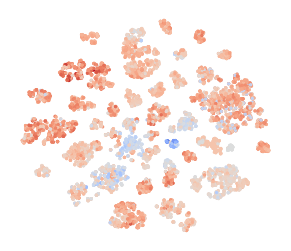

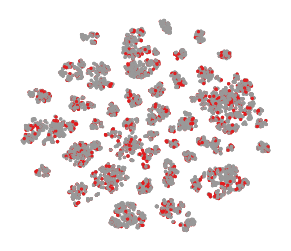

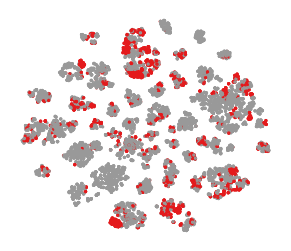

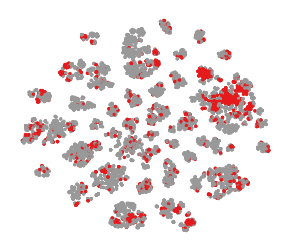

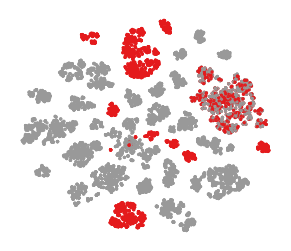

In [35]:
scatter_compounds("Assays", "assays", colors)
scatter_compounds("Activity", "activity", d[ACT], cmap="coolwarm")
cmap = "Set1"
scatter_compounds("Random split", "random", d["random train"], cmap=cmap)
scatter_compounds("Scaffold split", "scaffold", d["scaffold train"], cmap=cmap)
# scatter_compounds("UMAP split", "umap", d["umap train"], cmap=cmap)
scatter_compounds("Butina split", "butina", d["butina train"], cmap=cmap)
scatter_compounds("Assay split", "assay", d["assay train"], cmap=cmap)

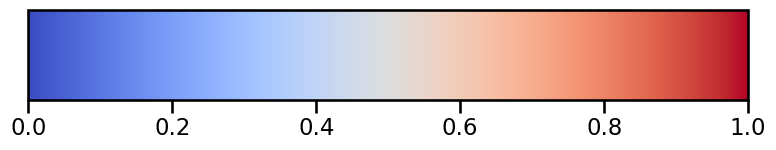

In [22]:
import pylab as pl
import numpy as np

a = np.array([[0, 1]])
pl.figure(figsize=(9, 1.5))
img = pl.imshow(a, cmap="coolwarm")
pl.gca().set_visible(False)
cax = pl.axes([0.1, 0.2, 0.8, 0.6])
pl.colorbar(orientation="horizontal", cax=cax)
pl.savefig("coolwarm.pdf")